#### 패션 MNIST 분류 예제 퀴즈 ####

1. 데이터 로드 및 전처리: keras.datasets.fashion_mnist.load_data()를 사용하여 데이터를 로드하고, 픽셀 값을 0과 1 사이로 정규화합니다.

2. CNN 모델 구성:
 - Conv2D: Convolutional Layer (합성곱 층)으로, 이미지에서 특징을 추출합니다.
 - MaxPooling2D: Max Pooling Layer (최대 풀링 층)으로, 특징 맵의 크기를 줄여 계산량을 줄이고 과적합을 방지합니다.
 - Flatten: Flatten Layer (평탄화 층)으로, 2차원 특징 맵을 1차원 벡터로 변환합니다.
 - Dense: Fully Connected Layer (완전 연결 층)으로, 모든 뉴런이 서로 연결되어 있습니다.
 - softmax: 출력층의 활성화 함수로, 각 클래스에 대한 확률을 반환합니다.

3. 모델 컴파일: 손실 함수, 옵티마이저, 평가 지표를 설정합니다.

4. 모델 훈련: model.fit() 함수를 사용하여 모델을 훈련합니다.

5. 모델 평가: model.evaluate() 함수를 사용하여 모델의 성능을 평가합니다.

6. 예측 및 시각화 (선택 사항): model.predict() 함수를 사용하여 테스트 이미지에 대한 예측을 수행하고, 결과를 시각화합니다.

<참고 자료 : import 라이브러리, 데이터 로드>


In [1]:
# 0: 티셔츠/탑 (T-shirt/top) 1: 바지 (Trouser) 2: 풀오버 (Pullover) 3: 드레스 (Dress) 4: 코트 (Coat) 5: 샌들 (Sandal) 6: 셔츠 (Shirt) 7: 스니커즈 (Sneaker) 8: 가방 (Bag) 9: 앵클 부츠 (Ankle boot)
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [2]:

# 데이터 로드
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 105s 4us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 58us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 7s 2us/step


In [9]:
# 클래스 이름 정의
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 이미지 픽셀 값을 0과 1사이로 정규화
train_images = train_images / 255.0
test_images = test_images / 255.0

In [3]:
# 데이터 reshape (CNN 입력을 위해)
train_images = train_images.reshape((60000, 28, 28, 1))
test_images = test_images.reshape((10000, 28, 28, 1))

In [4]:
# CNN 모델 구성
from tensorflow.keras import layers, models

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
# 모델 컴파일
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [6]:
# 모델 훈련
model.fit(train_images, train_labels, epochs=5, batch_size=64)

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.8062 - loss: 0.6196
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.8713 - loss: 0.3561
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8878 - loss: 0.3079
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.8985 - loss: 0.2760
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9034 - loss: 0.2595


In [7]:
# 모델 평가
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f'Test accuracy: {test_acc}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8852 - loss: 0.3309
Test accuracy: 0.885200023651123


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


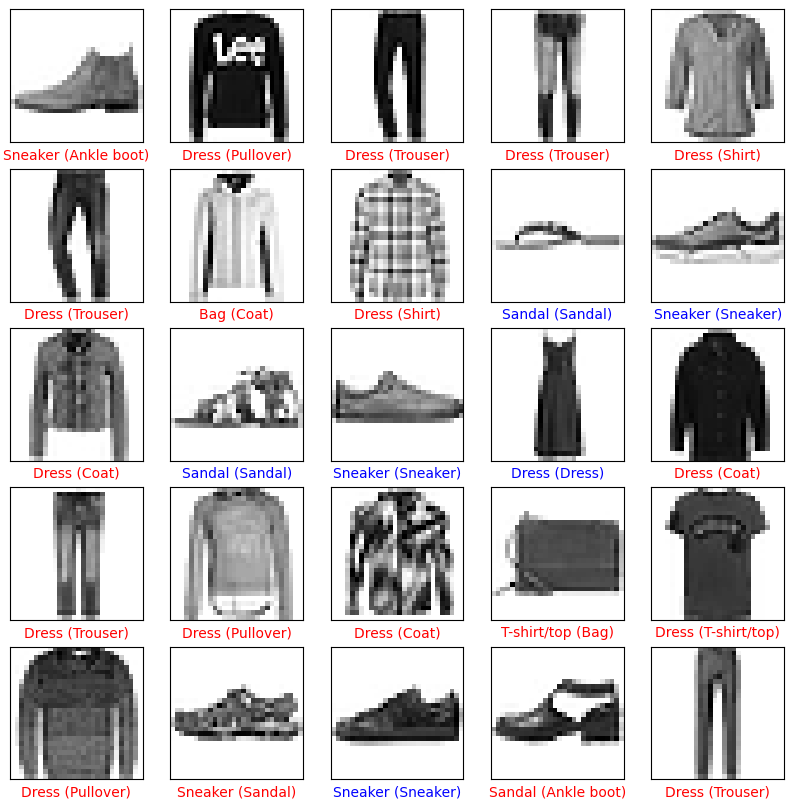

In [10]:
# 예측 및 시각화
predictions = model.predict(test_images)

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(test_images[i].reshape(28,28), cmap=plt.cm.binary)
    predicted_label = np.argmax(predictions[i])
    true_label = test_labels[i]
    color = 'blue' if predicted_label == true_label else 'red'
    plt.xlabel(f"{class_names[predicted_label]} ({class_names[true_label]})", color=color)
plt.show()